  RAW DATA STATISTICS (before normalisation)
     Feature |        Min |        Max |       Mean |        Std
-------------------------------------------------------
       Theta |     5.0000 |    45.0000 |    25.0000 |    14.1990
    L_Offset |     0.1000 |     1.0000 |     0.5500 |     0.3195
        Area |     0.0020 |     0.0100 |     0.0060 |     0.0028
   Max_Force |    29.1317 | 12636.9346 |  1534.1705 |  2130.9062

Real rows      : 125
Fold Force ranges after stratified split:
  Fold |    Min Force |    Max Force |   Mean Force
--------------------------------------------------
     1 |        29.13 |      7582.25 |      1481.14
     2 |        38.89 |      7834.94 |      1523.91
     3 |        54.89 |      9793.63 |      1746.16
     4 |        58.25 |     10109.59 |      1800.09
     5 |        77.76 |     12636.93 |      2024.95
     6 |        87.37 |      4460.19 |      1193.73
     7 |        89.24 |      5054.90 |      1275.10
     8 |        95.07 |      5560.27 |     

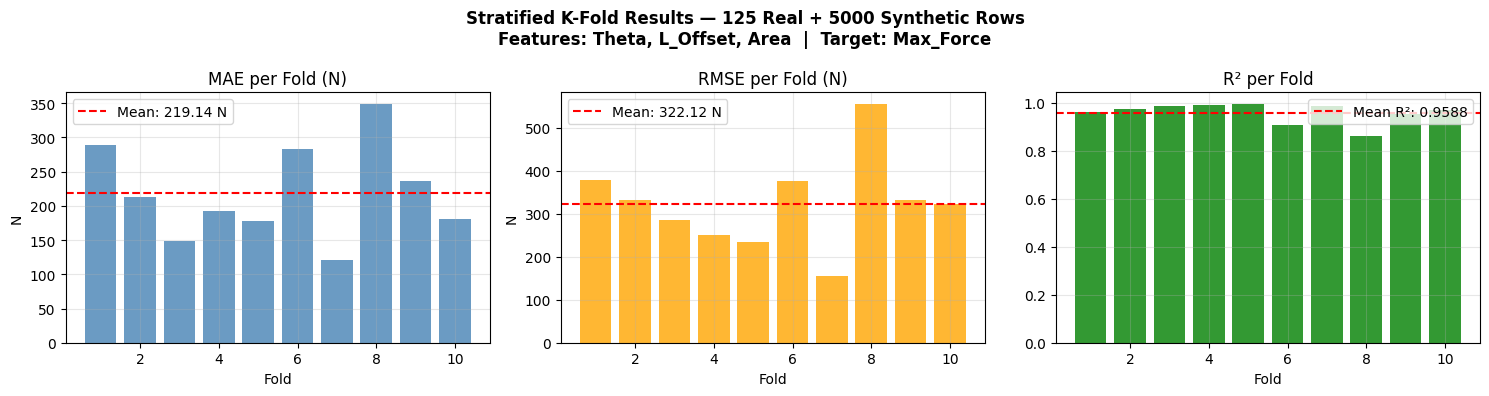

In [ ]:
# ============================================================
# DEEP LEARNING MODEL — STRATIFIED K-FOLD SPLIT
# Key fix: folds are split by Max_Force range, not randomly
# Every fold gets a representative sample of the full range
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# ── 1. Load & Shuffle Real Data ───────────────────────────────
df = pd.read_csv('Static Data 2')
df = df.drop(columns=['Unnamed: 0'])

n  = len(df)
df = df.sample(n=n, random_state=42).reset_index(drop=True)

FEATURE_COLS = ['Theta', 'L_Offset', 'Area']
TARGET_COL   = 'Max_Force'
N_SYNTHETIC  = 5000

X_real = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
y_real = torch.tensor(df[TARGET_COL].values,   dtype=torch.float32)

print(f"{'='*55}")
print(f"  RAW DATA STATISTICS (before normalisation)")
print(f"{'='*55}")
print(f"{'Feature':>12} | {'Min':>10} | {'Max':>10} | {'Mean':>10} | {'Std':>10}")
print(f"{'-'*55}")
for i, col in enumerate(FEATURE_COLS):
    print(f"{col:>12} | {X_real[:, i].min().item():>10.4f} | "
          f"{X_real[:, i].max().item():>10.4f} | "
          f"{X_real[:, i].mean().item():>10.4f} | "
          f"{X_real[:, i].std().item():>10.4f}")
print(f"{'Max_Force':>12} | {y_real.min().item():>10.4f} | "
      f"{y_real.max().item():>10.4f} | "
      f"{y_real.mean().item():>10.4f} | "
      f"{y_real.std().item():>10.4f}")
print(f"{'='*55}\n")
print(f"Real rows      : {n}")


# ── 2. Stratified K-Fold Split ────────────────────────────────
# Sort all rows by Max_Force, then assign fold numbers by cycling
# Row with rank 0   → Fold 0
# Row with rank 1   → Fold 1
# ...
# Row with rank K   → Fold 0  (cycles back)
# This guarantees every fold contains low, mid, and high Force values
ok
def stratified_kfold_indices(y, K, seed=42):
    torch.manual_seed(seed)
    sorted_idx  = torch.argsort(y)          # sort by target value
    fold_assign = torch.zeros(len(y), dtype=torch.long)

    for rank, idx in enumerate(sorted_idx):
        fold_assign[idx] = rank % K         # assign fold by cycling

    fold_indices = []
    for k in range(K):
        test_idx  = (fold_assign == k).nonzero(as_tuple=True)[0]
        train_idx = (fold_assign != k).nonzero(as_tuple=True)[0]
        fold_indices.append((train_idx, test_idx))

    return fold_indices

K = 10
fold_indices = stratified_kfold_indices(y_real, K)

# Print fold Force ranges to verify stratification worked
print(f"Fold Force ranges after stratified split:")
print(f"{'Fold':>6} | {'Min Force':>12} | {'Max Force':>12} | {'Mean Force':>12}")
print(f"{'-'*50}")
for k, (train_idx, test_idx) in enumerate(fold_indices):
    y_test_k = y_real[test_idx]
    print(f"{k+1:>6} | {y_test_k.min().item():>12.2f} | "
          f"{y_test_k.max().item():>12.2f} | "
          f"{y_test_k.mean().item():>12.2f}")
print()


# ── 3. Stratified Mixup ───────────────────────────────────────
def generate_stratified_mixup(X, y, n_synthetic, seed=42):
    torch.manual_seed(seed)
    n_real     = len(X)
    sorted_idx = torch.argsort(y)
    bin_size   = n_real // 3
    low_idx    = sorted_idx[:bin_size]
    mid_idx    = sorted_idx[bin_size:2*bin_size]
    high_idx   = sorted_idx[2*bin_size:]

    X_syn_list = []
    y_syn_list = []
    n_each     = n_synthetic // 3

    for idx_list in [(low_idx, high_idx), (low_idx, mid_idx)]:
        a_idx, b_idx = idx_list
        for _ in range(n_each):
            i   = a_idx[torch.randint(0, len(a_idx), (1,))].item()
            j   = b_idx[torch.randint(0, len(b_idx), (1,))].item()
            lam = torch.rand(1).item()
            X_syn_list.append(lam * X[i] + (1 - lam) * X[j])
            y_syn_list.append(lam * y[i] + (1 - lam) * y[j])

    remainder = n_synthetic - 2 * n_each
    for _ in range(remainder):
        i   = mid_idx[torch.randint(0, len(mid_idx),   (1,))].item()
        j   = high_idx[torch.randint(0, len(high_idx), (1,))].item()
        lam = torch.rand(1).item()
        X_syn_list.append(lam * X[i] + (1 - lam) * X[j])
        y_syn_list.append(lam * y[i] + (1 - lam) * y[j])

    return torch.stack(X_syn_list), torch.stack(y_syn_list)

X_syn, y_syn = generate_stratified_mixup(X_real, y_real, N_SYNTHETIC)
print(f"Synthetic rows : {N_SYNTHETIC}")
print(f"Total rows     : {n + N_SYNTHETIC}\n")


# ── 4. Dataset Class ──────────────────────────────────────────
class StructuralDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── 5. Model ──────────────────────────────────────────────────
class ForcePredictor_Small(nn.Module):
    def __init__(self, input_dim=3, dropout=0.0):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.output_layer(x)
        return x.squeeze(1)


# ── 6. Helper Functions ───────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        prediction = model(x_batch)
        loss = criterion(prediction, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_actuals = [], []
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)d
        prediction = model(x_batch)
        loss = criterion(prediction, y_batch)
        total_loss += loss.item() * len(x_batch)
        all_preds.append(prediction.cpu())
        all_actuals.append(y_batch.cpu())
    return total_loss / len(loader.dataset), torch.cat(all_preds), torch.cat(all_actuals)


# ── 7. Cross Validation ───────────────────────────────────────
NUM_EPOCHS = 500
PATIENCE   = 50
BATCH_SIZE = 128

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Device        : {device}")
print(f"K-Folds       : {K}  (stratified by Max_Force)")
print(f"Synthetic     : {N_SYNTHETIC} rows added to each train fold")
print(f"Epochs        : up to {NUM_EPOCHS} with patience {PATIENCE}\n")

fold_mae_list  = []
fold_rmse_list = []
fold_r2_list   = []

best_fold_mae        = float('inf')
best_fold_model      = None
best_fold_x_mean     = None
best_fold_x_std      = None
best_fold_y_mean     = None
best_fold_y_std  #    = None

print(f"{'Fold':>6} | {'Val MAE (N)':>12} | {'Val RMSE (N)':>13} | {'Val R²':>8}")
print("-" * 50)

for fold, (train_idx, test_idx) in enumerate(fold_indices):

    # ── Split real data ───────────────────────────────────────
    X_real_train = X_real[train_idx]
    y_real_train = y_real[train_idx]
    X_real_test  = X_real[test_idx]
    y_real_test  = y_real[test_idx]

    # ── Combine real train + synthetic ────────────────────────
    X_train_combined = torch.cat([X_real_train, X_syn], dim=0)
    y_train_combined = torch.cat([y_real_train, y_syn], dim=0)

    # ── Normalise using combined train statistics only ────────
    x_mean = X_train_combined.mean(dim=0)
    x_std  = X_train_combined.std(dim=0)
    y_mean = y_train_combined.mean()
    y_std  = y_train_combined.std()

    X_train_norm = (X_train_combined - x_mean) / x_std
    X_test_norm  = (X_real_test      - x_mean) / x_std
    y_train_norm = (y_train_combined - y_mean) / y_std
    y_test_norm  = (y_real_test      - y_mean) / y_std

    # ── Datasets and loaders ──────────────────────────────────
    train_ds = StructuralDataset(X_train_norm, y_train_norm)
    test_ds  = StructuralDataset(X_test_norm,  y_test_norm)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0, drop_last=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0,
    )

    # ── Fresh model for each fold ─────────────────────────────
    model     = ForcePredictor_Small(input_dim=3, dropout=0.0).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
    )

    # ── Train ─────────────────────────────────────────────────
    best_val_loss     = float('inf')
    best_model_state  = None
    epochs_no_improve = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss         = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, _, _     = evaluate(model, test_loader, criterion, device)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_model_state  = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            break

    # ── Evaluate ──────────────────────────────────────────────
    model.load_state_dict(best_model_state)
    _, y_pred_norm, y_actual_norm = evaluate(model, test_loader, criterion, device)

    y_pred_n   = (y_pred_norm   * y_std) + y_mean
    y_actual_n = (y_actual_norm * y_std) + y_mean

    y_pred_np   = y_pred_n.numpy()
    y_actual_np = y_actual_n.numpy()

    mae    = np.mean(np.abs(y_pred_np - y_actual_np))
    rmse   = np.sqrt(np.mean((y_pred_np - y_actual_np) ** 2))
    ss_res = np.sum((y_actual_np - y_pred_np) ** 2)
    ss_tot = np.sum((y_actual_np - y_actual_np.mean()) ** 2)
    r2     = 1 - (ss_res / (ss_tot + 1e-8))

    fold_mae_list.append(mae)
    fold_rmse_list.append(rmse)
    fold_r2_list.append(r2)

    print(f"{fold+1:>6} | {mae:>12.4f} | {rmse:>13.4f} | {r2:>8.4f}")

    if mae < best_fold_mae:
        best_fold_mae    = mae
        best_fold_model  = {k: v.clone() for k, v in model.state_dict().items()}
        best_fold_x_mean = x_mean.clone()
        best_fold_x_std  = x_std.clone()
        best_fold_y_mean = y_mean.clone()
        best_fold_y_std  = y_std.clone()

# ── 8. Final Summary ──────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  CROSS VALIDATION RESULTS ({K} folds)")
print(f"{'='*55}")
print(f"  Features     : {FEATURE_COLS}")
print(f"  Target       : {TARGET_COL}")
print(f"  Real rows    : {n}")
print(f"  Synthetic    : {N_SYNTHETIC}")
print(f"{'-'*55}")
print(f"  MAE          : {np.mean(fold_mae_list):.4f} N  ±  {np.std(fold_mae_list):.4f}")
print(f"  RMSE         : {np.mean(fold_rmse_list):.4f} N  ±  {np.std(fold_rmse_list):.4f}")
print(f"  R²           : {np.mean(fold_r2_list):.4f}    ±  {np.std(fold_r2_list):.4f}")
print(f"{'='*55}")

# ── 9. Save Best Fold Model ───────────────────────────────────
model.load_state_dict(best_fold_model)

torch.save({
    'model_state_dict' : best_fold_model,
    'x_mean'           : best_fold_x_mean,
    'x_std'            : best_fold_x_std,
    'y_mean'           : best_fold_y_mean,
    'y_std'            : best_fold_y_std,
}, 'Small_data_prediction.pt')

print(f"\nBest fold MAE  : {best_fold_mae:.4f} N")
print(f"Model saved    : Small_data_prediction.pt")

# ── 10. Inference ─────────────────────────────────────────────
def predict(model, x_mean, x_std, y_mean, y_std, theta, l_offset, area, device):
    model.eval()
    with torch.no_grad():
        x_raw  = torch.tensor([[theta, l_offset, area]], dtype=torch.float32)
        x_norm = (x_raw - x_mean) / x_std
        x_norm = x_norm.to(device)
        y_norm = model(x_norm)
        y_real = (y_norm.cpu() * y_std) + y_mean
    return y_real.item()

print(f"\n{'='*55}")
print(f"  INFERENCE EXAMPLES")
print(f"{'='*55}")
print(f"{'Theta':>8} | {'L_Offset':>10} | {'Area':>10} | {'Predicted (N)':>15}")
print(f"{'-'*55}")

test_inputs = [
    (25.0, 0.5,  0.005),
    (10.0, 0.2,  0.003),
    (45.0, 1.0,  0.010),
    (5.0,  0.1,  0.002),
    (35.0, 0.75, 0.008),
]

for theta, l_offset, area in test_inputs:
    prediction = predict(model, best_fold_x_mean, best_fold_x_std,
                         best_fold_y_mean, best_fold_y_std,
                         theta, l_offset, area, device)
    print(f"{theta:>8.1f} | {l_offset:>10.3f} | {area:>10.4f} | {prediction:>15.4f}")

print(f"{'='*55}")

# ── 11. Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f'Stratified K-Fold Results — {n} Real + {N_SYNTHETIC} Synthetic Rows\n'
    f'Features: Theta, L_Offset, Area  |  Target: Max_Force',
    fontweight='bold'
)

folds = range(1, K + 1)

axes[0].bar(folds, fold_mae_list, color='steelblue', alpha=0.8)
axes[0].axhline(np.mean(fold_mae_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_mae_list):.2f} N')
axes[0].set_title('MAE per Fold (N)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('N')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(folds, fold_rmse_list, color='orange', alpha=0.8)
axes[1].axhline(np.mean(fold_rmse_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_rmse_list):.2f} N')
axes[1].set_title('RMSE per Fold (N)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('N')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].bar(folds, fold_r2_list, color='green', alpha=0.8)
axes[2].axhline(np.mean(fold_r2_list), color='red', linestyle='--',
                label=f'Mean R²: {np.mean(fold_r2_list):.4f}')
axes[2].set_title('R² per Fold')
axes[2].set_xlabel('Fold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stratified_kfold_results.png', dpi=150, bbox_inches='tight')
plt.show()